### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [199]:
data = pd.read_csv('coupons.csv')

In [200]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [201]:
data.tail(10)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12676,Home,Alone,Sunny,80,6PM,Restaurant(20-50),1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12677,Home,Partner,Sunny,30,6PM,Restaurant(<20),1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,1
12678,Home,Partner,Sunny,30,10PM,Restaurant(<20),2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,1,0,0
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0
12683,Work,Alone,Sunny,80,7AM,Restaurant(20-50),2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0


2. Investigate the dataset for missing or problematic data.

In [202]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [203]:
data.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
12679,False
12680,False
12681,False
12682,False


In [204]:
data.duplicated().sum()



np.int64(74)

In [205]:
data[data.duplicated()]


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4280,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
4324,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,46,Single,...,never,4~8,1~3,1~3,1,1,1,0,1,1
4409,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,21,Single,...,never,less1,1~3,never,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,Home,Alone,Sunny,80,6PM,Bar,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1
8512,Home,Partner,Sunny,30,10PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,1
8513,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0
8515,Work,Alone,Snowy,30,7AM,Restaurant(20-50),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0


**The # of duplicated rows is too small compared to the overall rows i.e. 74 and keeping them as is as shouldn't impact the results. In addition,
its hard to know if they are actual duplicates as they don't have individual identifier information to distinguish.**

In [206]:
data.isna().sum()


,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


**Looks like most of the columns have data, the column "car" has the largest values but as most of the other columns largely have data so don't have to remove any rows, We could potentially remove the "car" column but don't think its going to impact any of the analysis and plots.**

3. Decide what to do about your missing data -- drop, replace, other...

**Keeping duplicate rows and null columns as is as don't believe they are large enough to skew the results.**

In [207]:
# Keeping rows as is, no need for changes

4. What proportion of the total observations chose to accept the coupon?



In [208]:
data['Y'].value_counts()
data['Y'].value_counts(normalize=True) * 100

# ~56% drivers chose to accept the coupon

,proportion
Y,
1,56.843267
0,43.156733


5. Use a bar plot to visualize the `coupon` column.

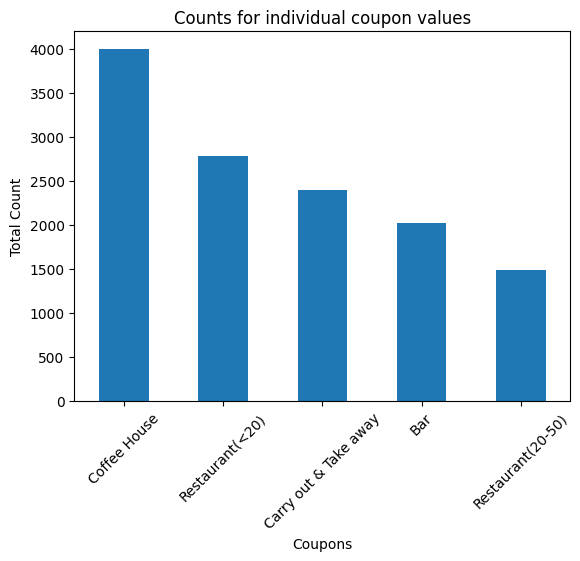

In [209]:
data.coupon.value_counts()
ax = data.coupon.value_counts().plot(kind='bar', title='Counts for individual coupon values')
ax.set_xlabel("Coupons")
ax.set_ylabel("Total Count")
plt.xticks(rotation=45)
plt.show()

# Coffee House seems to be the most popular coupon of choice with the highest acceptance rate

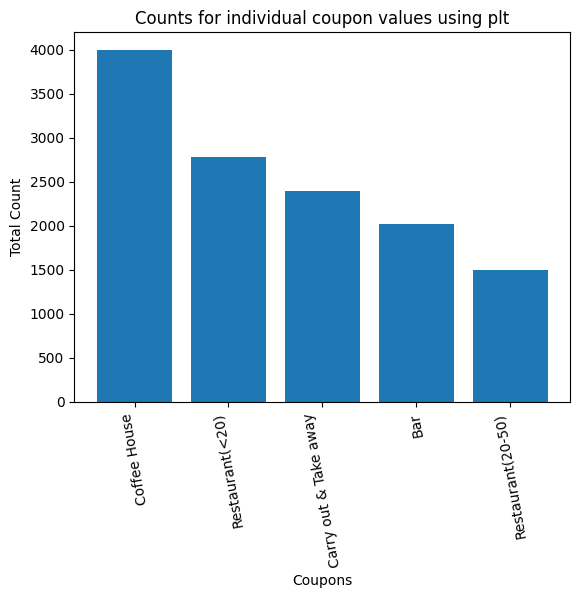

In [210]:
# Same data and plot but using matplotlib

plt.bar(data.coupon.value_counts().index, data.coupon.value_counts())
plt.xticks(rotation=100)
plt.xlabel('Coupons')
plt.ylabel('Total Count')
plt.title('Counts for individual coupon values using plt')
plt.show()

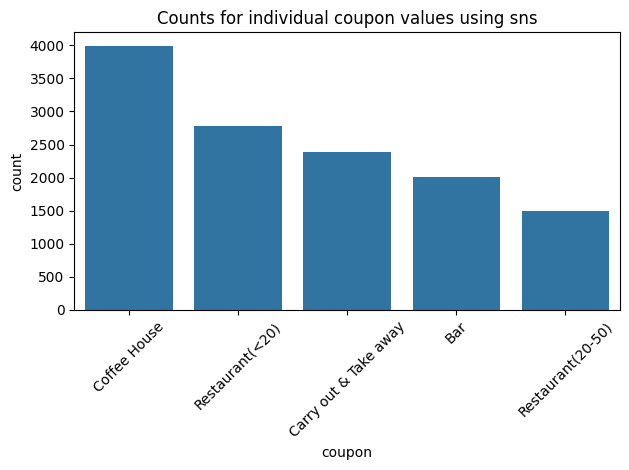

In [211]:
# Same data and plot but using seaborn

sns.barplot(data.coupon.value_counts())
plt.xticks(rotation=45)
plt.title('Counts for individual coupon values using sns')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

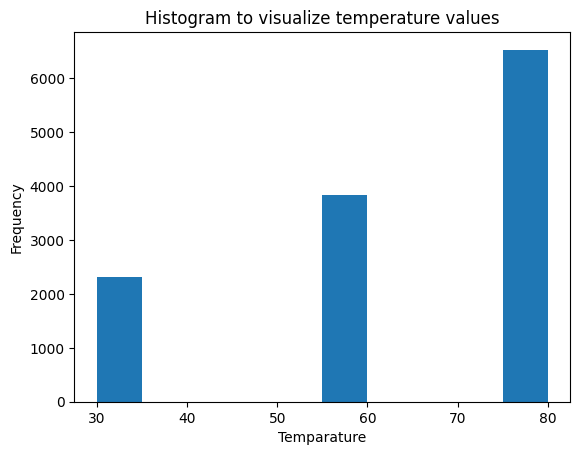

In [212]:
# plot for temperature as a histogram

data.temperature.value_counts()
data.temperature.plot(kind='hist')
plt.xlabel('Temparature')
plt.title('Histogram to visualize temperature values')
plt.show()


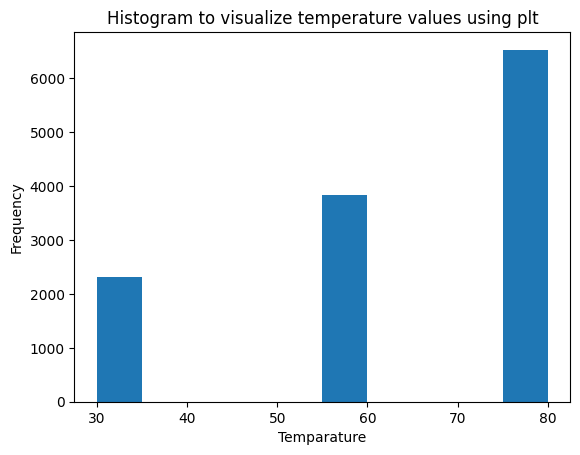

In [213]:
# plot for temperature as a histogram using plt

plt.hist(data.temperature)
plt.xlabel('Temparature')
plt.ylabel('Frequency')
plt.title('Histogram to visualize temperature values using plt')
plt.show()

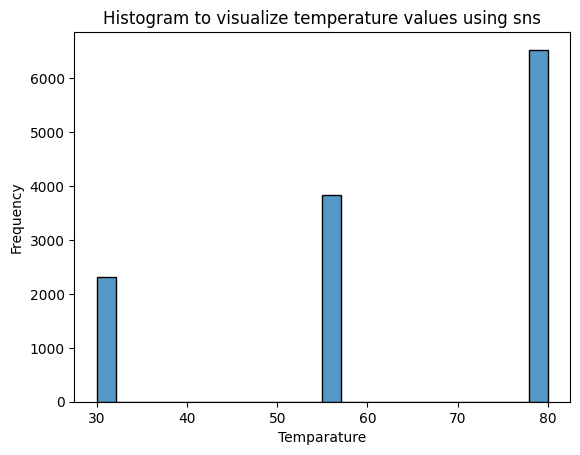

In [214]:
# plot for temperature as a histogram using seaborn

sns.histplot(data.temperature)
plt.xlabel('Temparature')
plt.ylabel('Frequency')
plt.title('Histogram to visualize temperature values using sns')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [215]:
# Loading data in barData after filtering on just the Bar values

barData = data[data.coupon == 'Bar']
barData.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [216]:
barData.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2017 entries, 9 to 12682
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           2017 non-null   object
 1   passanger             2017 non-null   object
 2   weather               2017 non-null   object
 3   temperature           2017 non-null   int64 
 4   time                  2017 non-null   object
 5   coupon                2017 non-null   object
 6   expiration            2017 non-null   object
 7   gender                2017 non-null   object
 8   age                   2017 non-null   object
 9   maritalStatus         2017 non-null   object
 10  has_children          2017 non-null   int64 
 11  education             2017 non-null   object
 12  occupation            2017 non-null   object
 13  income                2017 non-null   object
 14  car                   13 non-null     object
 15  Bar                   1996 non-null   obje

In [217]:
barData.tail()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


2. What proportion of bar coupons were accepted?


In [218]:
barData['Y'].value_counts()
barData['Y'].value_counts(normalize=True) * 100

# ~41% chose to accept the coupon

,proportion
Y,
0,58.998513
1,41.001487


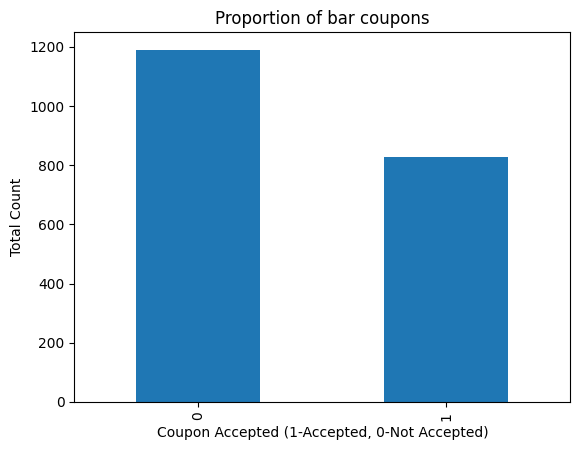

In [219]:
# Displaing the proportion of bar coupons as bar plot

barData.Y.value_counts().plot(kind='bar')
plt.xlabel('Coupon Accepted (1-Accepted, 0-Not Accepted)')
plt.ylabel('Total Count')
plt.title('Proportion of bar coupons')
plt.show()

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [220]:
#Create new dateframe to filter from barData set to only records where coupons were accepted

AcceptancebarData = barData[barData.Y == 1]
AcceptancebarData

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
75,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Male,46,Married partner,...,1~3,1~3,1~3,less1,1,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,21,Single,...,never,1~3,1~3,less1,1,1,0,0,1,1
12573,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,21,Single,...,never,1~3,1~3,less1,1,1,0,0,1,1
12591,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Female,50plus,Divorced,...,less1,1~3,1~3,less1,1,1,0,0,1,1
12644,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,1


In [221]:
# Acceptance rate between those who went to a bar 3 or fewer times a month compared to those who went more more

AcceptancebarData.Bar.isnull().sum()
AcceptancebarData.Bar.value_counts()
AcceptancebarData.Bar.value_counts(normalize=True) * 100
#Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.
AcceptancebarData['Bar'].replace('1~3', '3 or fewer times').replace( 'less1', '3 or fewer times').replace('never', '3 or fewer times').replace('4~8','4 or more times').replace('gt8','4 or more times').value_counts(normalize=True) * 100

# 81% went 3 or fewer times to a bar when accepted coupon


,proportion
Bar,
3 or fewer times,81.318681
4 or more times,18.681319


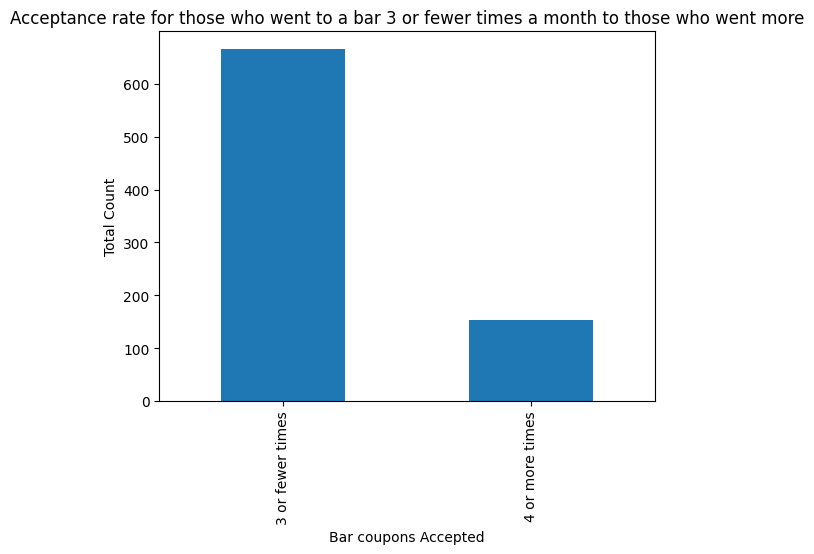

In [222]:
# Displaying acceptance rate data for those who went to a bar 3 or fewer times a month to those who went more

AcceptancebarData['Bar'].replace('1~3', '3 or fewer times').replace( 'less1', '3 or fewer times').replace('never', '3 or fewer times').replace('4~8','4 or more times').replace('gt8','4 or more times').value_counts().plot(kind='bar')
plt.xlabel('Bar coupons Accepted')
plt.ylabel('Total Count')
plt.title('Acceptance rate for those who went to a bar 3 or fewer times a month to those who went more')
plt.show()


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


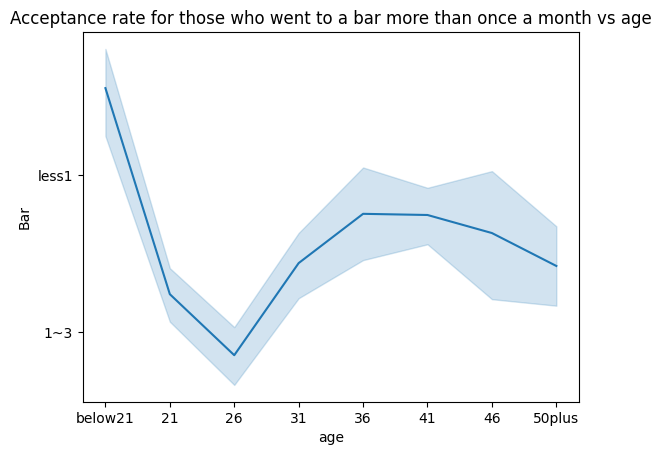

In [223]:


my_order = ["below21", "21", "26", "31", "36", "41", "46", "50plus"]
pd.options.mode.chained_assignment = None
# Convert the column to categorical with the specified order
AcceptancebarData['age'] = pd.Categorical(AcceptancebarData['age'], categories=my_order, ordered=True)
sns.lineplot(data=AcceptancebarData, x=AcceptancebarData.age, y=AcceptancebarData.Bar)
plt.title('Acceptance rate for those who went to a bar more than once a month vs age')
plt.show()

#Seems that around age 26, its at the highest rate for drivers who accepted and go to a bar more than once a month and starts reducing
# as you get older but starts peaking again after 35. Under the age of 25, the rate of acceptance is at the lowest levels.


**Based on above plot, seems that around age 26, drivers tend to have the highest rate of acceptance who go to bars more than once a month but it starts reducing as you get older. In addition, it starts peaking again after age 35. Under the age of 25, the rate of acceptance is at the lowest levels.**

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [224]:
# checking data and getting counts for coupon acceptance with passenger and occupation column counts per the conditions

AcceptancebarData.info()
AcceptancebarData.Bar.value_counts()
AcceptancebarData['passanger'].value_counts()
AcceptancebarData['occupation'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 13 to 12652
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   destination           827 non-null    object  
 1   passanger             827 non-null    object  
 2   weather               827 non-null    object  
 3   temperature           827 non-null    int64   
 4   time                  827 non-null    object  
 5   coupon                827 non-null    object  
 6   expiration            827 non-null    object  
 7   gender                827 non-null    object  
 8   age                   827 non-null    category
 9   maritalStatus         827 non-null    object  
 10  has_children          827 non-null    int64   
 11  education             827 non-null    object  
 12  occupation            827 non-null    object  
 13  income                827 non-null    object  
 14  car                   3 non-null      object  
 15  Bar     

,count
occupation,
Student,120
Unemployed,91
Computer & Mathematical,87
Sales & Related,80
Management,65
Office & Administrative Support,53
Business & Financial,41
Education&Training&Library,40
Arts Design Entertainment Sports & Media,33


19.709794437726725
80.29020556227327


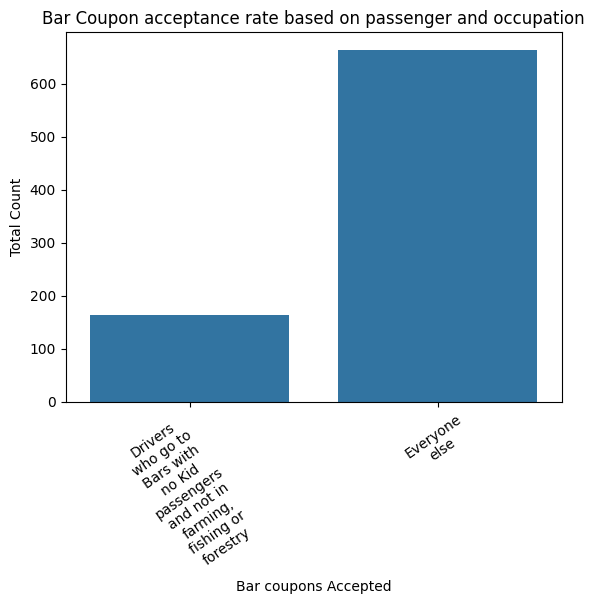

In [225]:
# Use the query filter to get the appropriate data for comparison and to use it to plot for visualization

import textwrap

meetnum5cond_df = AcceptancebarData.query("(Bar not in ['less1', 'never'] and passanger not in ['Alone', 'Kids(s)'] and occupation not in ['Farming Fishing & Forestry'])")
doesNotMeetnum5cond_df = AcceptancebarData.query("not (Bar not in ['less1', 'never'] and passanger not in ['Alone', 'Kids(s)'] and occupation not in ['Farming Fishing & Forestry'])")
A_cnt = len(meetnum5cond_df)
B_cnt = len(doesNotMeetnum5cond_df)
print(A_cnt/ (A_cnt + B_cnt)*100)
print(B_cnt/ (A_cnt + B_cnt)*100)

ax = sns.barplot(x=['Drivers who go to Bars with no Kid passengers and not in farming, fishing or forestry', 'Everyone else'], y=[A_cnt, B_cnt])

# Grab the labels, wrap them, and set them back
ax.set_xticks(np.arange(len(ax.get_xticklabels())))
ax.set_xticklabels([textwrap.fill(e.get_text(), 10) for e in ax.get_xticklabels()])

plt.xticks(rotation=35)
plt.xlabel('Bar coupons Accepted')
plt.ylabel('Total Count')
plt.title('Bar Coupon acceptance rate based on passenger and occupation')
plt.show()


# Based on the plot and counts, Seems only ~20% of the drivers have an acceptance rate with the conditions listed as part of the criteria.


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Group 1 Count: go to bars more than once a month, had passengers that were not a kid, and were not widowed -->  163
Group 2 Count: go to bars more than once a month and are under the age of 30 -->  252
Group 3 Count: go to cheap restaurants more than 4 times a month and income is less than 50K -->  156
 **** 


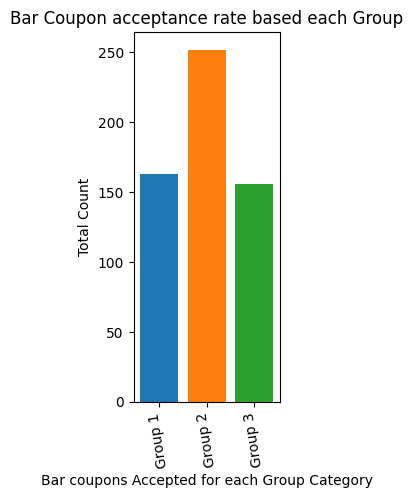

In [226]:
#AcceptancebarData.income.value_counts()
# calulcating the counts for each group based on the different conditions and then mapping to a subplot bar graph for comparison and visualization

cond_1 = AcceptancebarData.query("(Bar not in ['less1', 'never'] and passanger not in ['Alone', 'Kids(s)'] and maritalStatus not in ['Widowed'])")
cond_1_cnt = len(cond_1)
cond_2 = AcceptancebarData.query("(Bar not in ['less1', 'never'] and age in ['below21', '21', '26'])")
cond_2_cnt = len(cond_2)
cond_3 = AcceptancebarData.query("(RestaurantLessThan20 in ['4~8', 'gt8'] and income in ['Less than $12500', '$37500 - $49999', '$12500 - $24999', '$25000 - $37499'])")
cond_3_cnt = len(cond_3)

print('Group 1 Count: go to bars more than once a month, had passengers that were not a kid, and were not widowed --> ', cond_1_cnt)
print('Group 2 Count: go to bars more than once a month and are under the age of 30 --> ', cond_2_cnt)
print('Group 3 Count: go to cheap restaurants more than 4 times a month and income is less than 50K --> ', cond_3_cnt)
print(' **** ')

plt.subplot(1, 3, 1)
plt.bar('Group 1', cond_1_cnt)
plt.bar('Group 2', cond_2_cnt)
plt.bar('Group 3', cond_3_cnt)
plt.xticks(rotation=99)
plt.xlabel('Bar coupons Accepted for each Group Category')
plt.ylabel('Total Count')
plt.title('Bar Coupon acceptance rate based each Group')
plt.show()

# The acceptance rate is higher for drivers that go to bars more than once a month and are under the age of 30 compared to the other two categories.


**Based on the above graph and data, the acceptance rate is higher for drivers that go to bars more than once a month and are under the age of 30 compared to the other two groups.**

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [227]:
# See below summarized findings based on the graphs and data observations who accepted bhe bar coupons

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [228]:
data.coupon.value_counts()
# Exploring Coffee House as its the largest group with the coupon category

,count
coupon,
Coffee House,3996
Restaurant(<20),2786
Carry out & Take away,2393
Bar,2017
Restaurant(20-50),1492


In [229]:
# Create separate dataset based on Coffee House filter

CoffeeHouseData = data[data.coupon == 'Coffee House']
CoffeeHouseData.info()
CoffeeHouseData.head()


<class 'pandas.core.frame.DataFrame'>
Index: 3996 entries, 1 to 12681
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           3996 non-null   object
 1   passanger             3996 non-null   object
 2   weather               3996 non-null   object
 3   temperature           3996 non-null   int64 
 4   time                  3996 non-null   object
 5   coupon                3996 non-null   object
 6   expiration            3996 non-null   object
 7   gender                3996 non-null   object
 8   age                   3996 non-null   object
 9   maritalStatus         3996 non-null   object
 10  has_children          3996 non-null   int64 
 11  education             3996 non-null   object
 12  occupation            3996 non-null   object
 13  income                3996 non-null   object
 14  car                   37 non-null     object
 15  Bar                   3959 non-null   obje

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0


In [230]:
CoffeeHouseData.Y.value_counts()
CoffeeHouseData.Y.value_counts(normalize=True) * 100

# The coffee House coupon has almost a split acceptance and rejection ratio

,proportion
Y,
0,50.075075
1,49.924925


In [231]:
# Exploring Accepted records witin the Coffee House dataframe

CoffeeHouseDataAccepted = CoffeeHouseData[CoffeeHouseData.Y == 1]
CoffeeHouseDataAccepted.info()
CoffeeHouseDataAccepted.head()


<class 'pandas.core.frame.DataFrame'>
Index: 1995 entries, 12 to 12631
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1995 non-null   object
 1   passanger             1995 non-null   object
 2   weather               1995 non-null   object
 3   temperature           1995 non-null   int64 
 4   time                  1995 non-null   object
 5   coupon                1995 non-null   object
 6   expiration            1995 non-null   object
 7   gender                1995 non-null   object
 8   age                   1995 non-null   object
 9   maritalStatus         1995 non-null   object
 10  has_children          1995 non-null   int64 
 11  education             1995 non-null   object
 12  occupation            1995 non-null   object
 13  income                1995 non-null   object
 14  car                   19 non-null     object
 15  Bar                   1973 non-null   obj

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
16,Work,Alone,Sunny,55,7AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,1
21,Work,Alone,Sunny,55,7AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
45,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,1
48,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,1


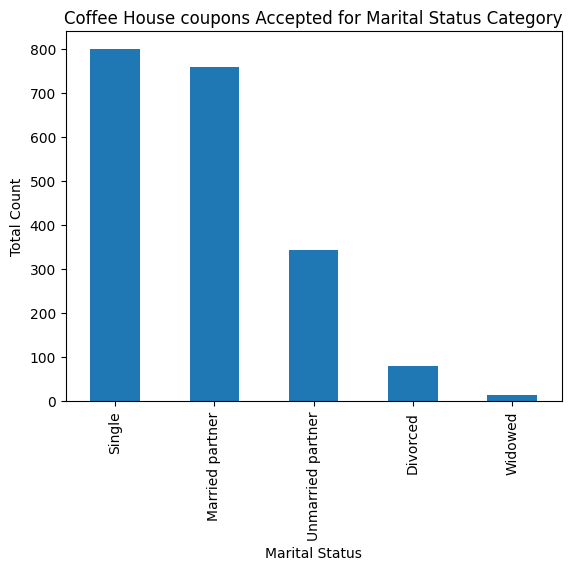

In [232]:
# Exploring Accepted coffee house coupon data based on marital Status

CoffeeHouseDataAccepted.maritalStatus.value_counts().plot(kind='bar')
plt.xlabel('Marital Status')
plt.ylabel('Total Count')
plt.title('Coffee House coupons Accepted for Marital Status Category')
plt.show()

# Singles and Married Partners tend to accept coupons for Coffee houses at a higher ratio

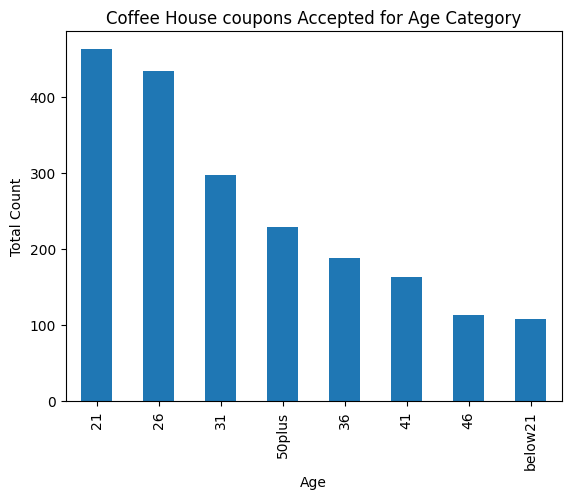

In [233]:
# Exploring Accepted coffee house coupon data based on age

CoffeeHouseDataAccepted.age.value_counts().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Total Count')
plt.title('Coffee House coupons Accepted for Age Category')
plt.show()

# 26 and younger tend to accept coupons for Coffee houses at a higher ratio

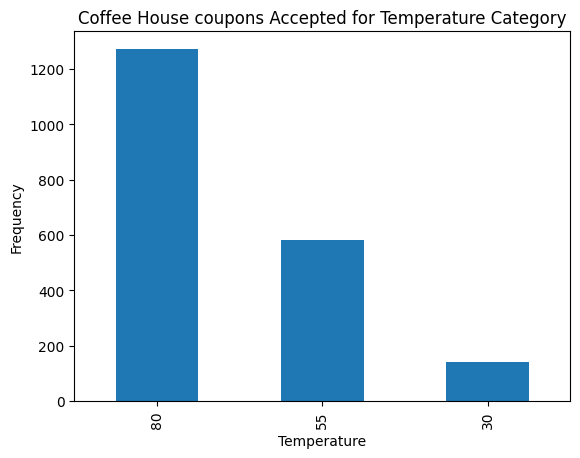

In [234]:
# Exploring Accepted coffee house coupon data based on Temperature

CoffeeHouseDataAccepted.temperature.value_counts().plot(kind='bar')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Coffee House coupons Accepted for Temperature Category')
plt.show()

# Was thinking that lower temparatures may have a higher ratio when going to coffee houses
# but seems that it peaks when the temparates are higher around 80 degrees.